In [ ]:
!pip install matplotlib

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("/home/vsingh/projects/chi-26/Evaluation/eval-phase2-questions.csv")
print(df.shape)
df.head()


(100, 32)


,The tool would be valuable for my day-to-day HR tasks.,The tool's features are useful and relevant to my professional responsibilities.,The tool would improve the efficiency of my work.,The tool would help me make better decisions.,I would use this tool frequently if it were available to me.,I would recommend this tool to other HR Managers.,The tool reveals HR perspectives and topics that were previously unknown to me.,The tool improves my understanding of global HRM perspectives on managing gig workers.,The tool helps me compare my local practices against global benchmarks for gig worker fairness.,I can apply the information from the tool to improve gig work conditions.,...,I found the system very cumbersome to use.,I felt very confident using the system.,I needed to learn a lot of things before I could get going with this system.,The tool is efficient.,The tool is clear.,The tool is practical.,The tool is exciting.,The tool is interesting.,The tool is novel.,The tool is leading edge.
0,Somewhat agree,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat disagree,Somewhat agree,Somewhat agree,Somewhat agree,...,Somewhat disagree,Somewhat agree,Somewhat disagree,Strongly agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree
1,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Neither agree nor disagree,Somewhat agree,...,Somewhat disagree,Neither agree nor disagree,Somewhat disagree,Somewhat agree,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Somewhat disagree,Neither agree nor disagree
2,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,...,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree
3,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Somewhat agree,...,Strongly agree,Strongly agree,Somewhat agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,Somewhat agree,Somewhat agree,Strongly agree
4,Strongly agree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,...,Strongly disagree,Strongly agree,Strongly disagree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree


In [13]:
# ----------------------------
# 2. Map Likert scale text → numeric
# ----------------------------
likert_map = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5,
    "Extremely uncomfortable": 1,
    "Somewhat uncomfortable": 2,
    "Neither comfortable nor uncomfortable": 3,
    "Somewhat comfortable": 4,
    "Extremely comfortable": 5,
    "Extremely negative": 1,
    "Somewhat negative": 2,
    "Somewhat positive": 4,
    "Extremely positive": 5,
    "Not at all useful": 1,
    "Slightly useful": 2,
    "Moderately useful": 3,
    "Very useful": 4,
    "Extremely useful": 5,
    "Extremely unsatisfied": 1,
    "Somewhat unsatisfied": 2,
    "Somewhat satisfied": 3,
    "Extremely satisfied": 5,
}

df_stats = df.replace(likert_map)

/tmp/ipykernel_754205/4129757471.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_stats = df.replace(likert_map)


In [15]:
df_stats.head()
df_stats.to_csv('SUS.csv', index=False)

In [5]:

# ----------------------------
# 3. Descriptive Statistics
# ----------------------------
desc_stats = df_stats.agg(['mean', 'median', 'std']).T
print("Descriptive Statistics:\n", desc_stats)

Descriptive Statistics:
                                                     mean  median       std
The tool would be valuable for my day-to-day HR...  4.11     4.0  0.983654
The tool's features are useful and relevant to ...  4.17     4.0  0.974990
The tool would improve the efficiency of my work.   4.08     4.0  0.981444
The tool would help me make better decisions.       4.17     4.0  0.910711
I would use this tool frequently if it were ava...  4.03     4.0  1.058444
I would recommend this tool to other HR Managers.   4.32     5.0  0.863163
The tool reveals HR perspectives and topics tha...  3.91     4.0  0.964993
The tool improves my understanding of global HR...  4.20     4.0  0.828775
The tool helps me compare my local practices ag...  4.19     4.0  0.849183
I can apply the information from the tool to im...  4.26     4.0  0.773553
The tool gives me new insights about my organiz...  4.17     4.0  0.943398
The tool supports evidence-based decision-makin...  4.21     4.0  0.807728


In [6]:

# ----------------------------
# 4. Frequency Counts (per question)
# ----------------------------
counts = df_stats.apply(pd.Series.value_counts).fillna(0).astype(int)
print("\nResponse Counts:\n", counts)


Response Counts:
    The tool would be valuable for my day-to-day HR tasks.  \
1                                                  2        
2                                                  8        
3                                                  7        
4                                                 43        
5                                                 40        

   The tool's features are useful and relevant to my professional responsibilities.  \
1                                                  1                                  
2                                                  8                                  
3                                                 10                                  
4                                                 35                                  
5                                                 46                                  

   The tool would improve the efficiency of my work.  \
1                                  

/tmp/ipykernel_754205/2799964242.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

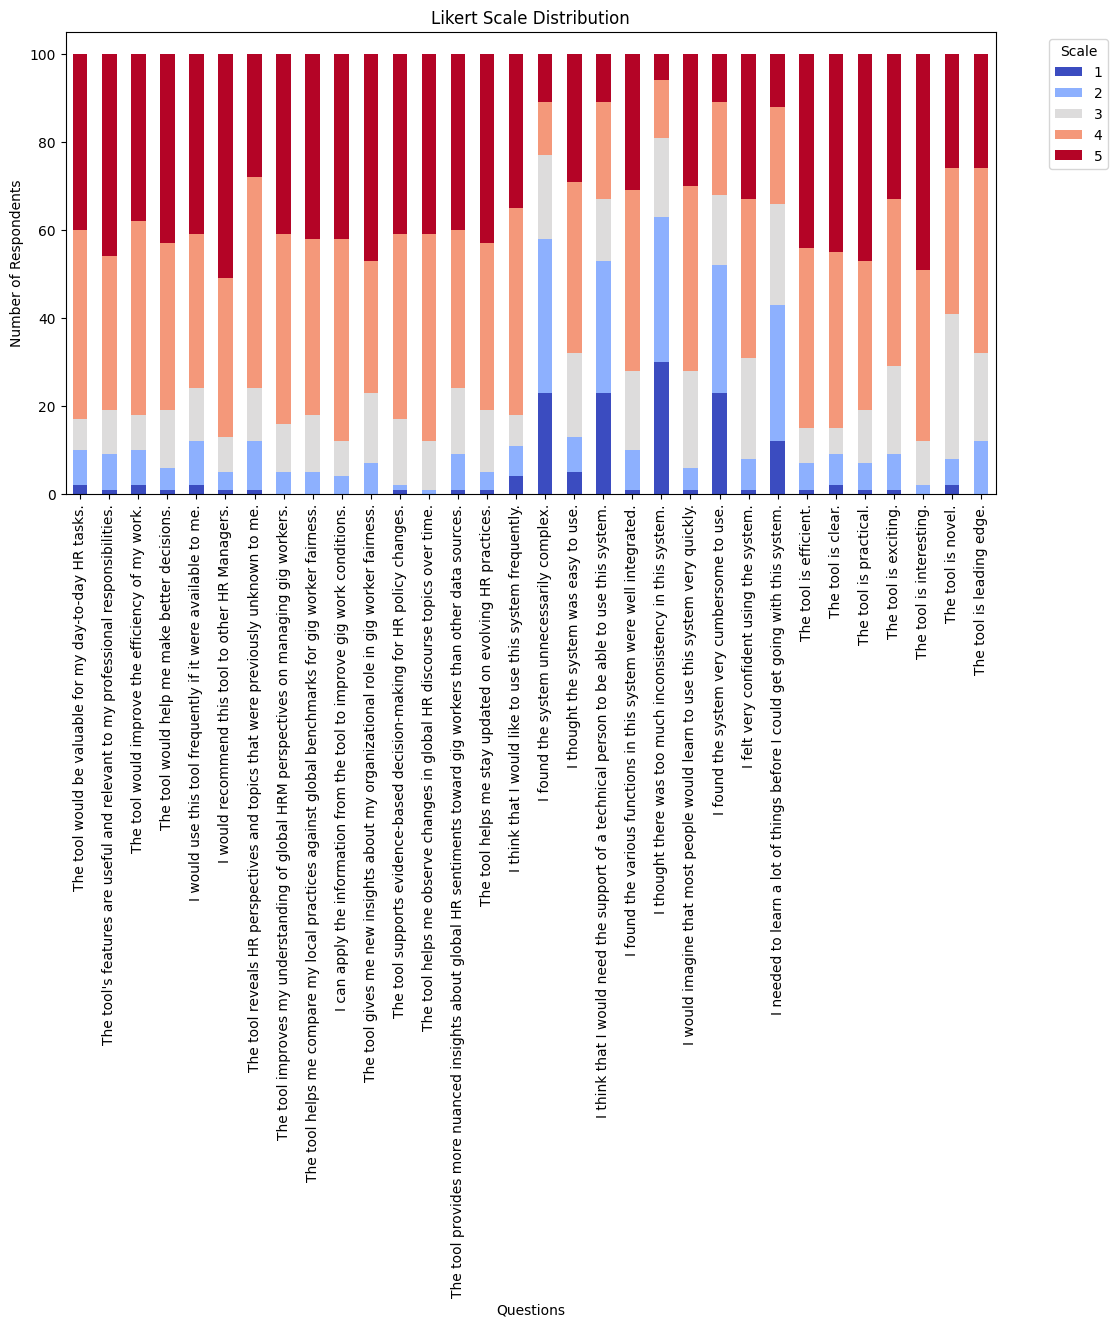

In [7]:
# ----------------------------
# 5. Visualization: Stacked Bar Plot
# ----------------------------
plt.figure(figsize=(12, 6))
counts.T.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(12, 6))
plt.xlabel('Questions')
plt.ylabel('Number of Respondents')
plt.title('Likert Scale Distribution')
plt.legend(title='Scale', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:

# ----------------------------
# 6. Reliability: Cronbach’s Alpha
# ----------------------------
def cronbach_alpha(df_subset):
    df_corr = df_subset.corr()
    n_items = len(df_subset.columns)
    mean_corr = df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool)).mean().mean()
    return (n_items * mean_corr) / (1 + (n_items - 1) * mean_corr)

alpha = cronbach_alpha(df_stats)
print(f"\nCronbach's Alpha: {alpha:.2f}")


Cronbach's Alpha: 0.95


In [9]:

# ----------------------------
# 7. Correlation Between Questions
# ----------------------------
correlation_matrix = df_stats.corr()
print("\nCorrelation Matrix:\n", correlation_matrix)


Correlation Matrix:
                                                     The tool would be valuable for my day-to-day HR tasks.  \
The tool would be valuable for my day-to-day HR...                                           1.000000        
The tool's features are useful and relevant to ...                                           0.685967        
The tool would improve the efficiency of my work.                                            0.754593        
The tool would help me make better decisions.                                                0.700557        
I would use this tool frequently if it were ava...                                           0.734139        
I would recommend this tool to other HR Managers.                                            0.660033        
The tool reveals HR perspectives and topics tha...                                           0.457473        
The tool improves my understanding of global HR...                                           0.629

In [10]:
# ----------------------------
# 8. Export results
# ----------------------------
desc_stats.to_csv("likert_summary_phase2.csv")
counts.to_csv("likert_counts_phase2.csv")
correlation_matrix.to_csv("likert_correlations_phase2.csv")
with open("cronbach_alpha_phase2.txt", "w") as f:
    f.write(f"Cronbach's Alpha: {alpha:.2f}\n")
